### Implement multi layer perceptron (MLP) -- character level language model. 

[referenece video](https://www.youtube.com/watch?v=TCH_1BHY58I)

In [223]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [224]:
# read all words
words = open('assets/names.txt').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [225]:
len(words) 

32033

In [226]:
# build the vocabulary of characters and mapping to/from integers

chars = sorted(list(set(''.join(words))))
stoi = { ch: i+1 for i, ch in enumerate(chars) }
stoi['.'] = 0
itos = { i: ch for ch, i in stoi.items() }
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [227]:
# build the dataset

block_size = 3  # context lenght of how many characters to consider to predict the next one
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--> ', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y) 



emma
... -->  e
..e -->  m
.em -->  m
emm -->  a
mma -->  .
olivia
... -->  o
..o -->  l
.ol -->  i
oli -->  v
liv -->  i
ivi -->  a
via -->  .
ava
... -->  a
..a -->  v
.av -->  a
ava -->  .
isabella
... -->  i
..i -->  s
.is -->  a
isa -->  b
sab -->  e
abe -->  l
bel -->  l
ell -->  a
lla -->  .
sophia
... -->  s
..s -->  o
.so -->  p
sop -->  h
oph -->  i
phi -->  a
hia -->  .


In [228]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [229]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [230]:
# embedding lookup table 'C'
# 27 possible characters, lets try putting them in 2D lookup table

C = torch.randn((27, 2))

C[5]

tensor([0.8372, 0.9787])

In [231]:
# embedding lookup using one_hot

F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# this will result in error without conversion as F.dtype is float32



tensor([0.8372, 0.9787])

In [232]:
# pytorch indexing is flexible. we can do with list, tensor of integers, we can repeat rows too
print(C[[5, 6, 7]] == C[torch.tensor([5,6,7])])

C[torch.tensor([5,6,7, 7, 7, 7])]

tensor([[True, True],
        [True, True],
        [True, True]])


tensor([[ 0.8372,  0.9787],
        [-1.3568,  1.0600],
        [-2.1715,  1.6189],
        [-2.1715,  1.6189],
        [-2.1715,  1.6189],
        [-2.1715,  1.6189]])

In [233]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [234]:
# weights and biases
w1 = torch.randn((6, 100))
b1 = torch.randn((100,))

In [235]:
# linear layer
#emb @ w1 + b1
# this will not work as emb = torch.size([32, 3, 2]) and w1 = torch.size([6, 100])  so we need to reshape emb
# Ww need to contact the last two dimensions of emb to make it compatible with w1

# ways to concat

print("before concat")
print("emb[0] ->", emb[0])
print("emb.shape ->", emb.shape)

torch_concat_emb = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
print("\nafter concat on first dimention")
print("emb[0] ->", torch_concat_emb[0])
print("emb.shape ->", torch_concat_emb.shape)

# torch.unwind
print("\nafter concat using torch.unbind")
torch_unwind_emb = torch.cat(torch.unbind(emb, 1), 1)
print("emb[0] ->", torch_unwind_emb[0])
print("emb.shape ->", torch_unwind_emb.shape)

# thorch.view
print("\nafter concat using torch.view")
torch_view_emb = emb.view(32, 6)
print("emb[0] ->", torch_view_emb[0])
print("emb.shape ->", torch_view_emb.shape)

print("\n\nall contcats equal ->", torch.equal(torch_view_emb, torch_unwind_emb) and torch.equal(torch_unwind_emb, torch_concat_emb))


# torch.view is the most efficient method to concat due to how tensor is stored in memory.
# In view method, we are not creating new tensor, we are just changing the view of the tensor.
# So, it is the most efficient way to concat tensors.
 
# This can be verified by calling .storage() on tensor which is the underlying storage of the tensor.
# View changes other attributes of tensor like shape, strides, offset etc but not the storage.

# more info on this -http://blog.ezyang.com/2019/05/pytorch-internals/


before concat
emb[0] -> tensor([[ 1.4255, -1.0800],
        [ 1.4255, -1.0800],
        [ 1.4255, -1.0800]])
emb.shape -> torch.Size([32, 3, 2])

after concat on first dimention
emb[0] -> tensor([ 1.4255, -1.0800,  1.4255, -1.0800,  1.4255, -1.0800])
emb.shape -> torch.Size([32, 6])

after concat using torch.unbind
emb[0] -> tensor([ 1.4255, -1.0800,  1.4255, -1.0800,  1.4255, -1.0800])
emb.shape -> torch.Size([32, 6])

after concat using torch.view
emb[0] -> tensor([ 1.4255, -1.0800,  1.4255, -1.0800,  1.4255, -1.0800])
emb.shape -> torch.Size([32, 6])


all contcats equal -> True


In [236]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
# these are numbers between 1 and -1 and shape is 32, 100
h

tensor([[-0.9375,  0.2940,  0.8479,  ...,  0.3376, -0.9189,  0.1143],
        [-0.8910, -0.9782,  0.8901,  ..., -0.9733, -0.9993, -0.6405],
        [-0.4526, -0.8162,  0.9724,  ...,  0.2708,  0.5512, -0.9533],
        ...,
        [-0.9462, -0.9924, -0.9838,  ...,  0.9951,  0.9985,  0.4006],
        [-0.8765, -0.9726,  0.7292,  ...,  0.9998,  0.6826,  0.9260],
        [-0.8218, -0.9999,  0.9803,  ...,  0.9994,  0.5771, -0.4220]])

In [237]:
# input 100 and output 27 which are possible characters
w2 = torch.randn((100, 27))
b2 = torch.randn((27,))

In [238]:
logits = h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [239]:
counts = logits.exp()

In [240]:
prob = counts / counts.sum(dim=1, keepdim=True) # softmax

print(prob.shape)
print(prob[0].sum()) # should be 1 as its normalized

torch.Size([32, 27])
tensor(1.)


In [241]:
# negative log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()

In [242]:
# -------- summarizing and cleaning code -------------- #

In [243]:
X, Y = [], []
block_size = 3  # context lenght of how many characters to consider to predict the next one

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y) 
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [244]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
w1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
w2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [245]:
sum(p.nelement() for p in parameters)

3481

In [246]:
for p in parameters:
    # p.requires_grad = True
    p.requires_grad_()

In [247]:
# training loop

for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    # three lines below can be replaced by F.cross_entropy which is much more efficient due to pytorch implementation
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdim=True) # softmax
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y)
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= p.grad * 0.1

19.505229949951172
17.084487915039062
15.776531219482422
14.83333683013916
14.002595901489258
13.253254890441895
12.579911231994629
11.983097076416016
11.470491409301758
11.05185604095459


In [248]:
# when we process full dataset we have 220k samples instead of 32 previously.
# we are doing way too much work forwarding and backwarding on 220k dataset. 
# we can do this in minibatches and optimize the iteration.

for _ in range(10):
    # minibatching
    # this is much faster than processing full dataset at once. Tradeoff:
    # quality of gradient descent is lower and is not as reliable.
    # But its good enough and worthy tradeoff for speed.
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= p.grad * 0.1 # learning rate 0.1


# here we are not interating over all 220k but on 32 samples in minibatch.
# due to this quality of grandiant discent is lower and is not as reliable.
# But its good enough and worthy tradeoff for speed. 


8.578198432922363
10.576653480529785
12.019200325012207
8.405226707458496
9.074337005615234
11.52615737915039
9.40711784362793
8.753418922424316
9.311753273010254
9.480487823486328


In [249]:
# current learning rate is 0.1, how do we validate or caulate the correct learning rate?

lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre # 0.001 to 1

In [250]:
lri = []
lossi = []

In [251]:
for i in range(10000):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    lri.append(lre[i])
    lossi.append(loss.item())

7.218667030334473
8.341472625732422
7.669432640075684
9.493534088134766
8.580320358276367
8.454163551330566
8.861358642578125
9.695833206176758
6.37298059463501
7.252065658569336
7.252882480621338
7.63953971862793
7.99656343460083
8.189702987670898
8.585124969482422
8.169670104980469
9.400408744812012
8.052908897399902
8.753194808959961
7.042685031890869
7.861356258392334
7.6627516746521
7.664623260498047
9.565826416015625
10.800843238830566
9.015027046203613
10.219552993774414
7.742188930511475
8.009557723999023
9.268430709838867
11.32170295715332
9.236616134643555
7.466019630432129
8.80888557434082
9.918058395385742
9.011259078979492
9.962717056274414
9.281007766723633
8.770073890686035
8.331147193908691
8.06338119506836
6.028750419616699
8.145315170288086
9.006043434143066
8.735896110534668
8.827275276184082
10.142463684082031
9.691424369812012
9.685779571533203
11.119483947753906
8.366597175598145
7.985511779785156
9.42307186126709
9.645471572875977
8.331498146057129
7.961169242858

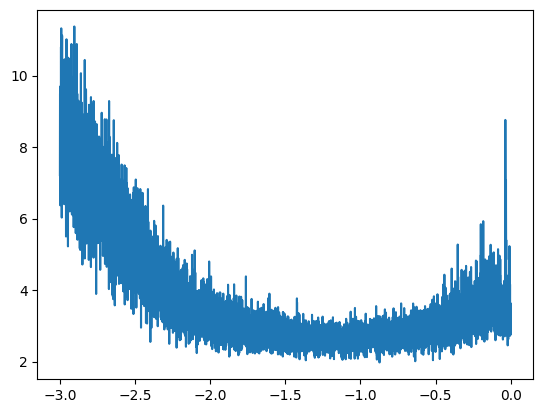

In [252]:
plt.plot(lri, lossi)

# plot looks like a hockey stick
# in beginning, learning rate is too low 
# then we reach a nice spot at ~0.1
# then it starts to diverge and becomes unstable learning rate is too high

In [253]:
# current loss
print(loss.item())

2.7865662574768066


In [254]:
# learning rate decay.

# after training for the model, at the end, we do a learning rate delay and go slower.

In [255]:
for i in range(1000):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Y[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += p.grad * -0.01 # learning rate decay

print(loss.item())

2.3941237926483154


In [256]:
# splitting up dataset into training, validation and test set

# we dramatically improved on loss at ~2.0 wrt biagram mode.
# this is not exactly true, this is a very small model but 
# models can be very big in millions of parameters and 100s of neurons.
# the more the model grows, the more it can memorize the data and overfit.
# due to that we can reduce the model loss even to almost 0 but
# it will not generalize well to unseen data.
# to fix it, fairly standard process is to split the data into training, validation and test set.

# training set - used to train the model
# validation set - used to tune hyperparameters, learning rate, batch size, model size etc.
# test set - used to evaluate the model on unseen data.


In [257]:
# rough split.
# training set - 80%, validation set - 10%, test set - 10%

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [258]:
len(words), n1, n2, n2-n1

(32033, 25626, 28829, 3203)

### dataset for training

In [259]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [260]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
w1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
w2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [261]:
sum(p.nelement() for p in parameters)

for p in parameters:
    # p.requires_grad = True
    p.requires_grad_()

lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre # 0.001 to 1

lri = []
lossi = []

In [285]:
for i in range(10000):
    # minibatching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

2.803682565689087


In [286]:
# calculate loss on dev set
emb = C[Xdev] # 32 x 3 x 2
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
logits = h @ w2 + b2

loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.7230, grad_fn=<NllLossBackward0>)

we can see both dev and training loss are about equal.
This model is not powerful enough to overfit the data and is underfillting as both losses are similar.

This means, we expect to improve model performance by scaling up the size of neural network as current network is tiny.



In [264]:
# The easiest way to do this to increase the size of neural network is to increase the no of neurons in hidden layer

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
w1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
w2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [265]:
# its now 10k parameters
print(sum(p.nelement() for p in parameters))

for p in parameters:
    # p.requires_grad = True
    p.requires_grad_()

lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre # 0.001 to 1

10281


In [266]:
lri = []
lossi = []
stepi = []

In [290]:
for i in range(30000):
    # minibatching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

2.260220766067505


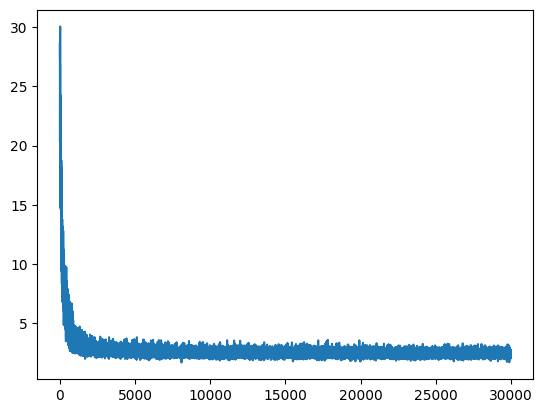

In [268]:
plt.plot(stepi, lossi)

In [291]:
# calculate loss on training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
logits = h @ w2 + b2

loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3164, grad_fn=<NllLossBackward0>)

In [292]:
# calculate loss on dev set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
logits = h @ w2 + b2

loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3153, grad_fn=<NllLossBackward0>)

one other concern is, the bottleneck of model is emdebbing that is 2-dimension. We are cramming too many characters in 2-dimension and neural network is not able to use the increased space effectively. 

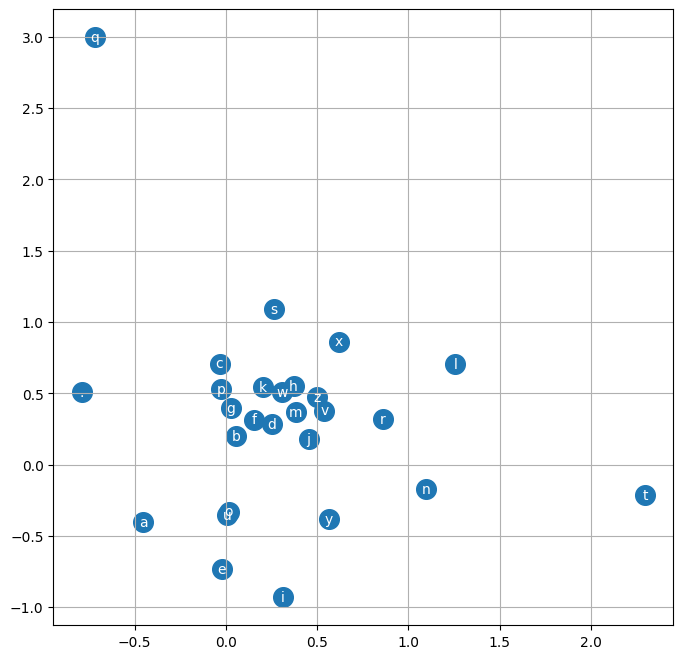

In [293]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
# emdebbing dimension is 2, so we can plot it in 2D
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

few observation above
- model has learned similarities in words, like vowels (a, e, i, o, u) are grouped together and dot (.) is sperated from other alphabets. embedding for them is similar.
- similarly q and t are sepearted as emdedding for these are very different.

#### increasing embedding dimension

In [313]:
# increase to 10 dimensions
# also decrease neurons size to 200

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
w1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
w2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [314]:
# its now 10k parameters
print(sum(p.nelement() for p in parameters))

for p in parameters:
    # p.requires_grad = True
    p.requires_grad_()

lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre # 0.001 to 1

lri = []
lossi = []
stepi = []

11897


In [316]:
for i in range(30000):
    # minibatching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # changed to 30
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item()) # log10 for better visualization as loss is decreasing exponentially

print(loss.item())

2.2210004329681396


In [321]:
for i in range(10000):
    # minibatching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # changed to 30
    logits = h @ w2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += p.grad * -lr # learning rate
    
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item()) # log10 for better visualization as loss is decreasing exponentially

print(loss.item())

1.8216094970703125


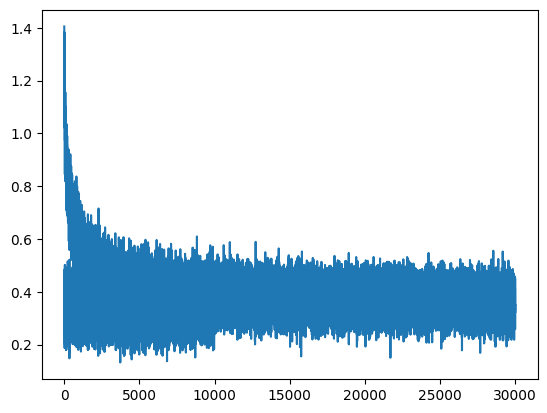

In [322]:
plt.plot(stepi, lossi)

In [323]:
# calculate loss on training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ w1 + b1)
logits = h @ w2 + b2

loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1510, grad_fn=<NllLossBackward0>)

In [324]:
# calculate loss on dev set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ w1 + b1)
logits = h @ w2 + b2

loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1865, grad_fn=<NllLossBackward0>)

There are any ways to go from here:
- tuning the optimizations further
- increase the size of nural network
- increase no of characters/words (from current 3) -- context?

## Sample from model

In [327]:
# we can see that output is much better than bigram model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amori.
killimri.
reetlenna.
sancer.
hubedemerric.
kaqui.
ner.
kia.
chaiir.
kaleigh.
ham.
porries.
juza.
lilea.
jadis.
watthon.
jarynix.
kaekiilsa.
mel.
